In [1]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
df= pd.read_csv('/kaggle/input/company-sales/company.csv')

In [3]:
df.head(20)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
5,8.7,48.9,75.0,7.2
6,57.5,32.8,23.5,11.8
7,120.2,19.6,11.6,13.2
8,8.6,2.1,1.0,4.8
9,199.8,2.6,21.2,15.6


In [4]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


# Checking for Correlation

<Axes: >

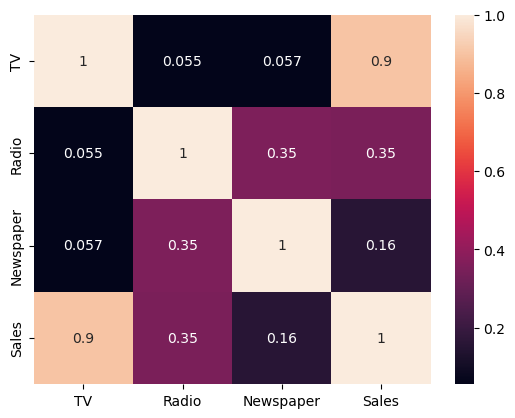

In [6]:
correlation_matrix= df.corr(method='pearson')

sns.heatmap(correlation_matrix, annot=True)

Text(0.5, 1.0, 'Sales Vs TV')

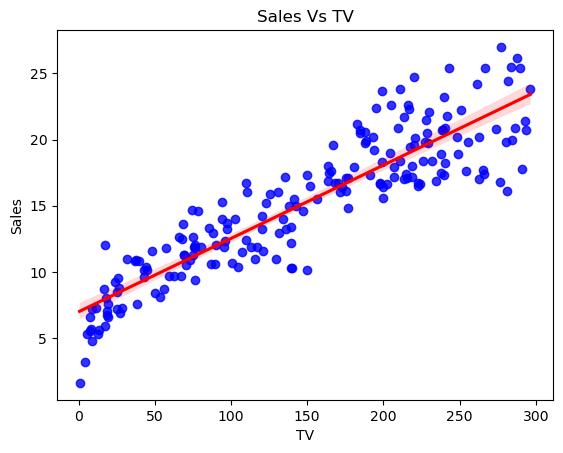

In [7]:
sns.regplot(x='TV',y='Sales',data=df,scatter_kws={'color':'blue'},line_kws={'color':'red'})
plt.title('Sales Vs TV')

**Strong positive correlation between TV and Sales**

# linear Regression

In [8]:
x= df[['TV']]
y=df[['Sales']]

x_train, x_test, y_train, y_test= train_test_split(x, y,test_size=0.3, random_state=42)

In [9]:
results = sm.OLS(y_train, x_train).fit()
print(results.summary())

                                 OLS Regression Results                                
Dep. Variable:                  Sales   R-squared (uncentered):                   0.939
Model:                            OLS   Adj. R-squared (uncentered):              0.939
Method:                 Least Squares   F-statistic:                              2138.
Date:                Sun, 26 Nov 2023   Prob (F-statistic):                    2.78e-86
Time:                        16:54:16   Log-Likelihood:                         -396.18
No. Observations:                 140   AIC:                                      794.4
Df Residuals:                     139   BIC:                                      797.3
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [10]:
ml=LinearRegression()
ml.fit(x_train,y_train)

LinearRegression()

In [11]:
ml.predict([[180.8]])

/opt/conda/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[17.12070154]])

**TV advert of 180.8 our prediction model got 16.92 as against 17.9.**

In [12]:
ml.predict([[69.2]])

/opt/conda/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[11.00112851]])

**with tv advert of 69.2 our model predicted 10.89 as against 11.3,** 

**with more analysis we could get a nearly perfect prediction model.**